In [1]:
!pip install lifelines -q

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 11.3 MB/s eta 0:00:00


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from lifelines import KaplanMeierFitter, CoxPHFitter

np.random.seed(42)

def generate_patients(
    n_patients=1000,
    closed_loop_effect_hours=3.0,
    cost_per_dropout=2000,
    stability_dropout_threshold=2.5,
    seed=42
):
    rng = np.random.default_rng(seed)

    df = pd.DataFrame({
        'patient_id': [f"P_{i:04d}" for i in range(n_patients)],
        'mode': rng.choice(['Closed-Loop', 'Manual'], n_patients),
        'pain_score_baseline': rng.integers(4, 10, n_patients),
        'device_stability_score': rng.uniform(1, 10, n_patients),
        'adherence_hours': rng.normal(12, 3, n_patients)
    })

    df.loc[df['mode'] == 'Closed-Loop', 'adherence_hours'] += closed_loop_effect_hours

    base_duration = (
        30
        + df['adherence_hours'] * 3
        + (df['device_stability_score'] - stability_dropout_threshold) * 4
        + rng.normal(0, 15, n_patients)
    )
    df['duration_days'] = np.clip(base_duration, 1, 180).round()

    observation_window = 90
    df['event_discontinued'] = (df['duration_days'] < observation_window).astype(int)
    df['duration_days'] = np.minimum(df['duration_days'], observation_window)

    df['cost_per_dropout'] = cost_per_dropout
    return df

df = generate_patients()
df.head()

,patient_id,mode,pain_score_baseline,device_stability_score,adherence_hours,duration_days,event_discontinued,cost_per_dropout
0,P_0000,Closed-Loop,8,1.558568,11.926413,47.0,1,2000
1,P_0001,Manual,8,5.124358,14.724189,90.0,0,2000
2,P_0002,Manual,7,2.161271,8.391910,56.0,1,2000
3,P_0003,Closed-Loop,9,2.370940,14.140902,75.0,1,2000
4,P_0004,Closed-Loop,4,6.690545,13.241845,90.0,0,2000


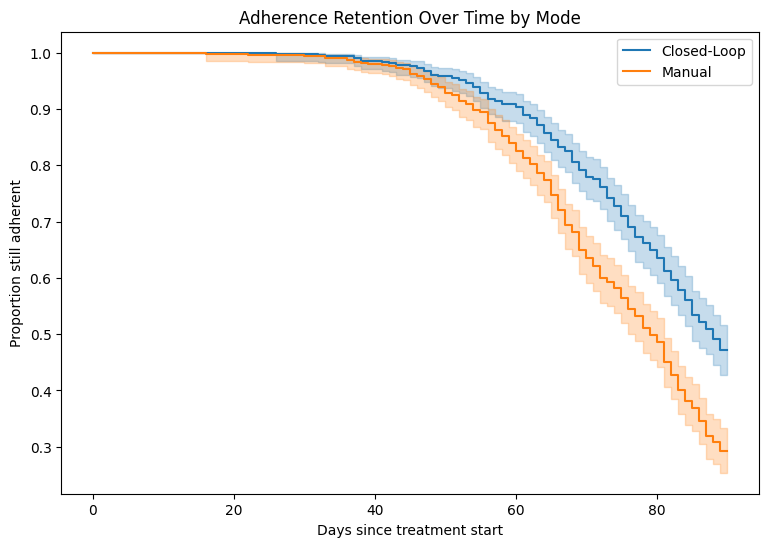

Closed-Loop: median survival = 88.0
Manual: median survival = 79.0


In [7]:
kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(9, 6))

for mode in ['Closed-Loop', 'Manual']:
    mask = df['mode'] == mode
    kmf.fit(df.loc[mask, 'duration_days'], df.loc[mask, 'event_discontinued'], label=mode)
    kmf.plot_survival_function(ax=ax)

ax.set_title('Adherence Retention Over Time by Mode')
ax.set_xlabel('Days since treatment start')
ax.set_ylabel('Proportion still adherent')
plt.show()

for mode in ['Closed-Loop', 'Manual']:
    mask = df['mode'] == mode
    kmf.fit(df.loc[mask, 'duration_days'], df.loc[mask, 'event_discontinued'], label=mode)
    print(f"{mode}: median survival = {kmf.median_survival_time_}")

In [4]:
cox_df = df.copy()
cox_df['mode_closed_loop'] = (cox_df['mode'] == 'Closed-Loop').astype(int)

cph = CoxPHFitter()
cph.fit(
    cox_df[['duration_days', 'event_discontinued', 'mode_closed_loop',
            'pain_score_baseline', 'device_stability_score']],
    duration_col='duration_days',
    event_col='event_discontinued'
)
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1000 total observations, 381 right-censored observations>
             duration col = 'duration_days'
                event col = 'event_discontinued'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 619
   partial log-likelihood = -3871.92
         time fit was run = 2026-07-02 20:51:26 UTC

---
                        coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                               
mode_closed_loop       -0.58      0.56      0.08           -0.74           -0.42                0.48                0.66
pain_score_baseline     0.01      1.01      0.02           -0.04            0.05                0.96                1.05
device_stability_score -0.27      0.77      0.02           -0.30           -0.23                0.74                0.79

                        cmp to      z      p  -log2(p)
covariate                                             
mode_closed_loop          0.00  -7.04 <0.005     38.94
pain_score_baseline       0.00   0.22   0.82      0.28
device_stability_score    0.00 -15.91 <0.005    186.82
---
Concordance = 0.71
Partial AIC = 7749.84
log-likelihood ratio test = 306.22 on 3 df
-log2(p) of ll-ratio test = 217.09

In [5]:
logit_model = smf.logit(
    'event_discontinued ~ mode + pain_score_baseline + device_stability_score',
    data=df
).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.530879
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     event_discontinued   No. Observations:                 1000
Model:                          Logit   Df Residuals:                      996
Method:                           MLE   Df Model:                            3
Date:                Thu, 02 Jul 2026   Pseudo R-squ.:                  0.2011
Time:                        20:51:42   Log-Likelihood:                -530.88
converged:                       True   LL-Null:                       -664.55
Covariance Type:            nonrobust   LLR p-value:                 1.159e-57
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                  2.3686      0.350      6.767      0.000       1.683      

   cost_per_dropout  total_dropouts  total_tvar
0              1000             619      619000
1              2000             619     1238000
2              3000             619     1857000
3              4000             619     2476000
4              5000             619     3095000


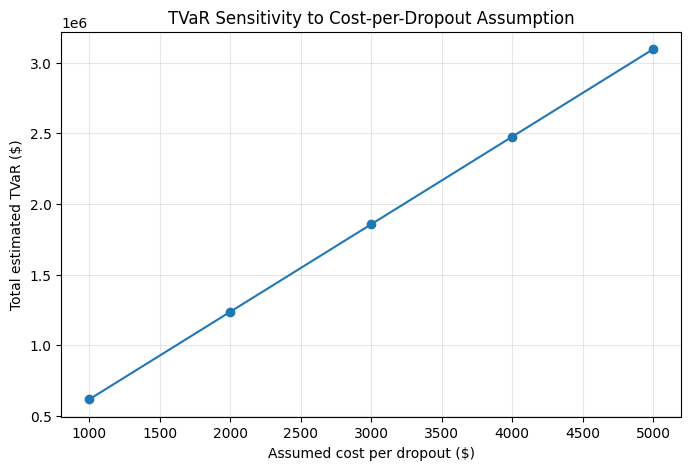

In [6]:
cost_assumptions = [1000, 2000, 3000, 4000, 5000]
results = []

for cost in cost_assumptions:
    total_dropouts = df['event_discontinued'].sum()
    total_risk = total_dropouts * cost
    results.append({'cost_per_dropout': cost, 'total_dropouts': total_dropouts, 'total_tvar': total_risk})

sensitivity_df = pd.DataFrame(results)
print(sensitivity_df)

plt.figure(figsize=(8, 5))
plt.plot(sensitivity_df['cost_per_dropout'], sensitivity_df['total_tvar'], marker='o')
plt.title('TVaR Sensitivity to Cost-per-Dropout Assumption')
plt.xlabel('Assumed cost per dropout ($)')
plt.ylabel('Total estimated TVaR ($)')
plt.grid(alpha=0.3)
plt.show()